In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amgothvijaykumar/text-sentiment-classification/main.csv


## Importing libraries 

In [2]:
import pandas as pd
import numpy as np

#visualiation
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

import warnings 
warnings.filterwarnings('ignore')

print("Libraries imported successfulyy")

Libraries imported successfulyy


## step1 Loading dataset

In [3]:
df=pd.read_csv('/kaggle/input/datasets/amgothvijaykumar/text-sentiment-classification/main.csv')
df.head()


,text,label
0,Layin n bed with a headache ughhhh...waitin o...,sadness
1,Funeral ceremony...gloomy friday...,sadness
2,@dannycastillo We want to trade with someone w...,neutral
3,"I should be sleep, but im not! thinking about ...",sadness
4,@charviray Charlene my love. I miss you,sadness


## step 2: understanding, cleaning

In [4]:
# : BASIC DATASET INFO

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (69298, 2)

Column Names:
Index(['text', 'label'], dtype='object')

Missing Values:
text     0
label    0
dtype: int64

Duplicate Rows: 148


In [5]:
# Removing duplicates 

print("Before removing duplicates: ",df.shape)
df=df.drop_duplicates()
print("After removing duplicates: ",df.shape)

Before removing duplicates:  (69298, 2)
After removing duplicates:  (69150, 2)


In [6]:
# Download NLTK DATA

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [7]:
#NLP utilities
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words=set(stopwords.words('english'))

# Important words to preserve
important_words = {
    'not',
    'no',
    'nor',
    'never',
    'very',
    'too',
    'so',
    'really',
    'just',
    'still',
    'again',
    'only'
}

# Remove them from stopwords
stop_words = stop_words - important_words

lemmatizer=WordNetLemmatizer()

In [8]:
#Text cleaning fun
def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove punctuation, numbers, special chars
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Stopword removal + Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [9]:
#Applying clean_text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,Layin n bed with a headache ughhhh...waitin o...,layin n bed headache ughhhh waitin call
1,Funeral ceremony...gloomy friday...,funeral ceremony gloomy friday
2,@dannycastillo We want to trade with someone w...,want trade someone houston ticket no one
3,"I should be sleep, but im not! thinking about ...",sleep im not thinking old friend want married ...
4,@charviray Charlene my love. I miss you,charlene love miss


In [10]:
#removing emplty rows
df = df[df['clean_text'].str.strip() != '']

print("Final Shape:", df.shape)

Final Shape: (68930, 3)


In [11]:
empty_rows_count = df.isna().all(axis=1).sum()
print("Empty rows count:", empty_rows_count)

Empty rows count: 0


## Step 3 Label Encoding + EDA + Visualization


In [12]:
print(df['label'].unique()) #unique labels

['sadness' 'neutral' 'surprise' 'love' 'anger' 'fear' 'joy']


In [13]:
#labels count
label_counts = df['label'].value_counts()

print(label_counts)

label
neutral     24413
sadness     13015
joy         10065
love         7326
anger        6562
surprise     3920
fear         3629
Name: count, dtype: int64


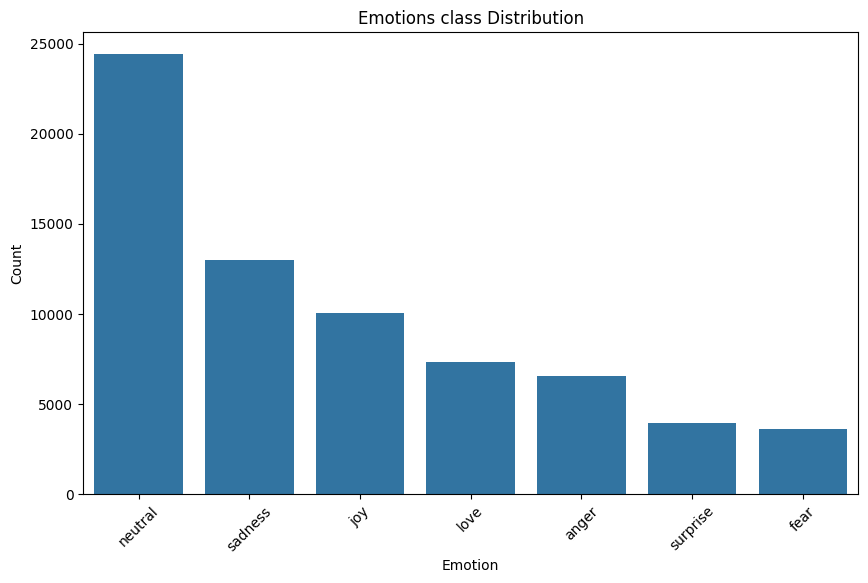

In [14]:
# CLASS DISTRIBUTION PLOT
plt.figure(figsize=(10,6))
sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

plt.title('Emotions class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

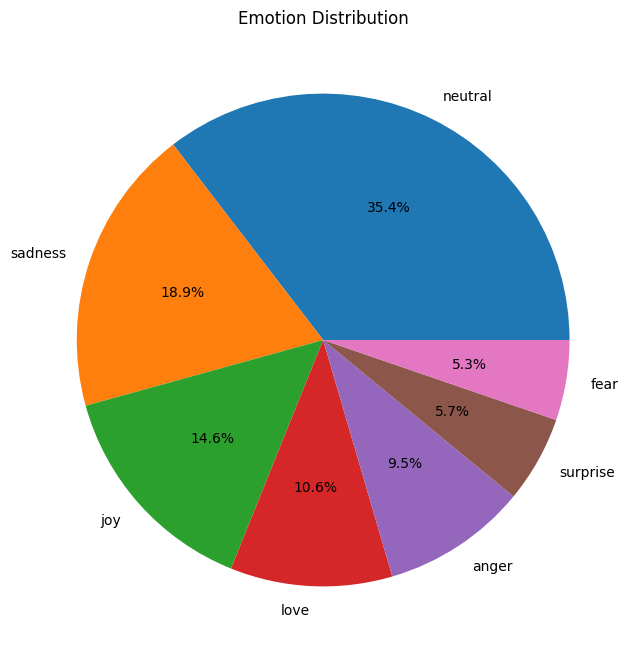

In [15]:
# PIE CHART

plt.figure(figsize=(8,8))

plt.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%'
)

plt.title("Emotion Distribution")

plt.show()

In [16]:

# TEXT LENGTH ANALYSIS

df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

df['text_length'].describe()

count    68930.000000
mean         7.764703
std          4.546000
min          1.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         40.000000
Name: text_length, dtype: float64

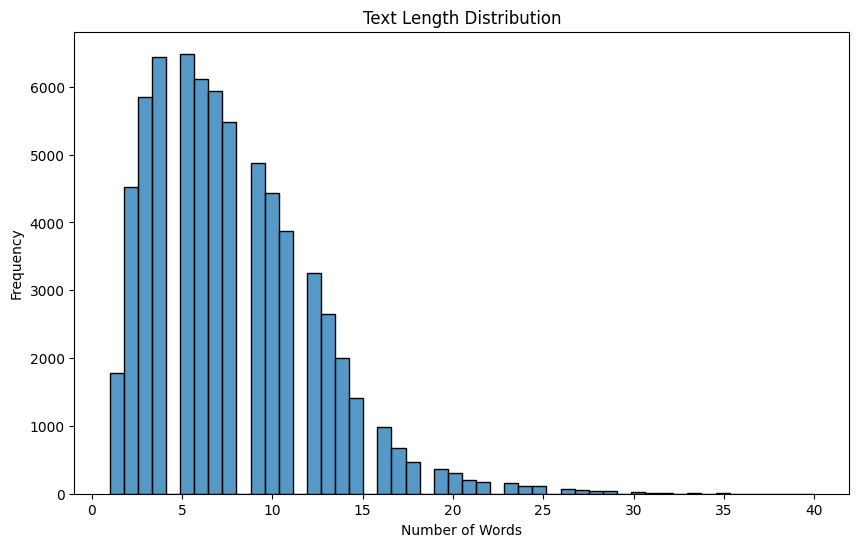

In [17]:
# TEXT LENGTH DISTRIBUTION

plt.figure(figsize=(10,6))

sns.histplot(df['text_length'], bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [18]:
from wordcloud import WordCloud, STOPWORDS

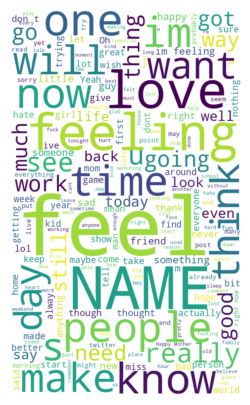

In [19]:
# Wordcloud: text
all_text = ' '.join(df['text'])

wordcloud = WordCloud(width = 600, height = 1000, stopwords = STOPWORDS,
                      random_state = 123, background_color = 'white').generate(all_text)

fig,ax = plt.subplots(figsize = (9,5))
ax.imshow(wordcloud, cmap = 'magma', interpolation = 'bilinear')
ax.axis('off')
fig.show()

In [20]:
# LABEL ENCODING

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label_encoded'] = encoder.fit_transform(df['label'])

df[['label', 'label_encoded']].head()

,label,label_encoded
0,sadness,5
1,sadness,5
2,neutral,4
3,sadness,5
4,sadness,5


In [21]:
# LABEL MAPPING

label_mapping = dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
))

print(label_mapping)

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'neutral': np.int64(4), 'sadness': np.int64(5), 'surprise': np.int64(6)}


## Step 4 — Train-Test Split + TF-IDF Vectorization

In [22]:
# FEATURES AND LABELS


X = df['clean_text']

y = df['label_encoded']

In [23]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (55144,)
Testing Size: (13786,)


In [24]:
# TF-IDF VECTORIZATION

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (55144, 10000)
X_test_tfidf shape: (13786, 10000)


## Step 5 — Train Logistic Regression Model

In [25]:
# IMPORT MODEL

from sklearn.linear_model import LogisticRegression

In [26]:
# CREATE MODEL

model = LogisticRegression(
    class_weight='balanced',
    max_iter=200
)

In [27]:
# TRAIN MODEL

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


## Step 6 — Model Evaluation

In [28]:
# MAKE PREDICTIONS

y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [29]:
# ACCURACY

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6748150297403163


In [ ]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.67      0.65      1312
           1       0.72      0.75      0.73       726
           2       0.78      0.73      0.75      2013
           3       0.63      0.65      0.64      1465
           4       0.72      0.70      0.71      4883
           5       0.75      0.64      0.69      2603
           6       0.29      0.47      0.36       784

    accuracy                           0.67     13786
   macro avg       0.64      0.66      0.65     13786
weighted avg       0.69      0.67      0.68     13786



In [ ]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 881   38   32   14  228   71   48]
 [  35  544   10   14   74   25   24]
 [  43   30 1469  131  204   64   72]
 [  24    7  141  954  167   65  107]
 [ 284   66  132  232 3419  282  468]
 [ 126   44   81  102  403 1670  177]
 [  22   27   28   64  222   55  366]]


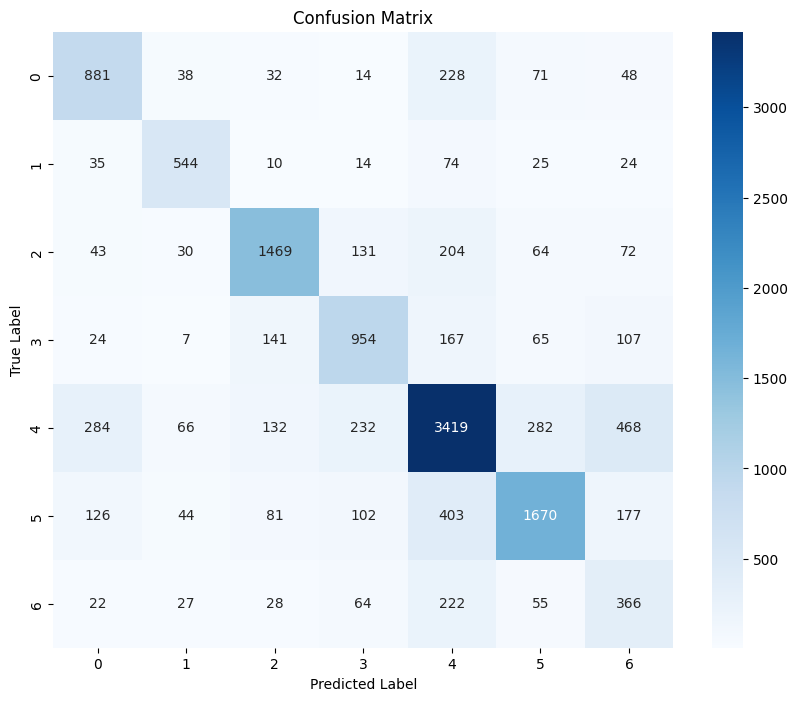

In [ ]:
# CONFUSION MATRIX HEATMAP


plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Step7 Saving the model and predictions 


In [ ]:
# IMPORT SVM

from sklearn.svm import LinearSVC

In [ ]:
# CREATE SVM MODEL

svm_model = LinearSVC(
    class_weight='balanced',
    max_iter=5000
)

In [ ]:
# TRAIN SVM MODEL


svm_model.fit(X_train_tfidf, y_train)

print("SVM training completed!")


SVM training completed!


In [ ]:
# SVM PREDICTIONS

svm_pred = svm_model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [ ]:
# SVM ACCURACY

from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.6802553314957203


In [ ]:
# SVM CLASSIFICATION REPORT

from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65      1312
           1       0.69      0.73      0.71       726
           2       0.76      0.73      0.75      2013
           3       0.63      0.64      0.63      1465
           4       0.72      0.72      0.72      4883
           5       0.73      0.66      0.70      2603
           6       0.33      0.39      0.36       784

    accuracy                           0.68     13786
   macro avg       0.64      0.65      0.64     13786
weighted avg       0.69      0.68      0.68     13786



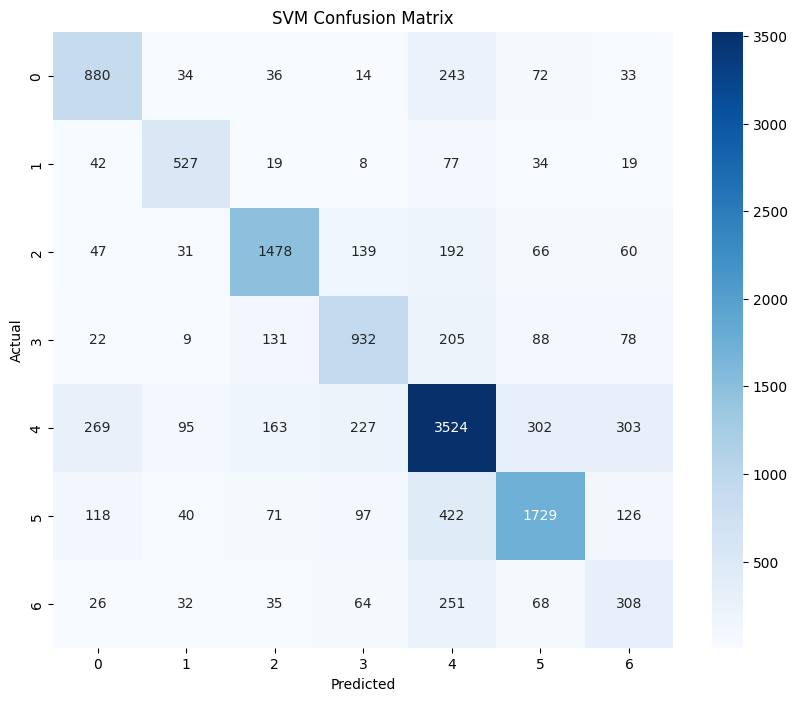

In [ ]:
# SVM CONFUSION MATRIX tried with svm to comapre with logistic regression

from sklearn.metrics import confusion_matrix

svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# REVERSE LABEL MAPPING

reverse_label_mapping = {
    v: k for k, v in label_mapping.items()
}

print(reverse_label_mapping)

{np.int64(0): 'anger', np.int64(1): 'fear', np.int64(2): 'joy', np.int64(3): 'love', np.int64(4): 'neutral', np.int64(5): 'sadness', np.int64(6): 'surprise'}


In [ ]:
# EMOTION PREDICTION FUNCTION

def predict_emotion(text):
    
    # Clean text
    cleaned = clean_text(text)
    
    # Convert to TF-IDF
    vectorized = tfidf.transform([cleaned])
    
    # Predict
    prediction = model.predict(vectorized)[0]
    
    # Probability
    probability = model.predict_proba(vectorized).max()
    
    # Convert label to emotion
    emotion = reverse_label_mapping[prediction]
    
    print(f"Text: {text}")
    print(f"Predicted Emotion: {emotion}")
    print(f"Confidence: {probability:.2f}")

In [ ]:
predict_emotion("I am extremely happy today!")

Text: I am extremely happy today!
Predicted Emotion: joy
Confidence: 0.49


In [ ]:
predict_emotion("I feel lonely and depressed")

Text: I feel lonely and depressed
Predicted Emotion: sadness
Confidence: 0.99


In [ ]:
predict_emotion("I love spending time with my family")

Text: I love spending time with my family
Predicted Emotion: love
Confidence: 0.81


In [ ]:
# SAVE MODEL

import pickle

# Save Logistic Regression model
with open('emotion_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)

# Save label encoder
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(encoder, file)

print("Model files saved successfully!")

Model files saved successfully!


In [ ]:
# LOAD SAVED MODEL AND PREDICT EMOTION

import pickle
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# LOAD SAVED FILES

with open('emotion_model.pkl', 'rb') as file:
    model = pickle.load(file)

with open('tfidf_vectorizer.pkl', 'rb') as file:
    tfidf = pickle.load(file)

with open('label_encoder.pkl', 'rb') as file:
    encoder = pickle.load(file)

print("Model and vectorizer loaded successfully!")


# NLP PREPROCESSING SETUP

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Stopwords
stop_words = set(stopwords.words('english'))

# Important words to preserve
important_words = {
    'not',
    'no',
    'nor',
    'never',
    'very',
    'too',
    'so',
    'really',
    'just',
    'still',
    'again',
    'only'
}

# Remove important words from stopwords
stop_words = stop_words - important_words

# Lemmatizer
lemmatizer = WordNetLemmatizer()


# TEXT CLEANING FUNCTION

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()

    # Stopword removal + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)



# PREDICTION FUNCTION


def predict_emotion(text):


    cleaned_text = clean_text(text)

    # Convert text to TF-IDF vector
    vectorized_text = tfidf.transform([cleaned_text])

    prediction = model.predict(vectorized_text)[0]

    probability = model.predict_proba(vectorized_text).max()

    emotion = encoder.inverse_transform([prediction])[0]

    print("\n==============================")
    print("Input Text:", text)
    print("Cleaned Text:", cleaned_text)
    print("Predicted Emotion:", emotion)
    print("Confidence Score:", round(probability * 100, 2), "%")
    print("==============================")



# TAKE USER INPUT


user_input = input("Enter your text: ")

predict_emotion(user_input)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Model and vectorizer loaded successfully!


Enter your text:  i dont like you



Input Text: i dont like you
Cleaned Text: dont like
Predicted Emotion: neutral
Confidence Score: 21.05 %
